In [1]:
import scanpy as sc
import pandas as pd
import palantir
import matplotlib.pyplot as plt

# Enable clean visual rendering directly below your notebook cells
%matplotlib inline
sc.settings.verbosity = 3

print("Environment loaded successfully.")

Environment loaded successfully.


In [2]:
# Read the file directly into an AnnData object
adata = sc.read_h5ad("obj_for_palantir.h5ad")

# Inspect the shape and core slots of your object
print(adata)

AnnData object with n_obs × n_vars = 6021 × 24437
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'RNA_snn_res.0.8', 'seurat_clusters', 'Sample_ID', 'percent.rb', 'umi_gene_ratio', 'cell_lineage', 'RNA_snn_res.1.5', 'Genotype_ID', 'unintegrated_clusters', 'Basal_Cell_signature_UCell', 'Ciliated_Cell_Signature_UCell', 'Club_Cell_Signature_UCell', 'AT1_Cell_Signature_UCell', 'AT2_Cell_Signature_UCell', 'AT2_15wk_Signature_UCell', 'Tabula_Muris_annotation', 'KPNull_annotation', 'LungMAP_annotation', 'epithelial_cell_type', 'harmony_clusters', 'NKX2.1_loss_score1', 'NKX2.1_high_score1', 'RUNX2_high_score1', 'transition_preEMT_score1', 'metastatic_score1', 'AT1_like_score1', 'early_gastric_score1', 'Late_gastric_score1', 'Inflammatory_score1', 'AT2_like_score1', 'Late_stage_score1', 'NKX2.1_loss_score_UCell', 'NKX2.1_high_score_UCell', 'RUNX2_high_score_UCell', 'transition_preEMT_score_UCell', 'metastatic_score_UCell', 'AT1_like_score_UCell', 'early_gastric_score_UCell', 

In [3]:
print("--- Integrated Embeddings Found (obsm) ---")
print(list(adata.obsm.keys()))

print("\n--- Metadata Columns Found (obs) ---")
# Look through this list for your final tumor state cluster column name
print(adata.obs.columns.tolist())

--- Integrated Embeddings Found (obsm) ---
['X_harmony', 'X_umap']

--- Metadata Columns Found (obs) ---
['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'RNA_snn_res.0.8', 'seurat_clusters', 'Sample_ID', 'percent.rb', 'umi_gene_ratio', 'cell_lineage', 'RNA_snn_res.1.5', 'Genotype_ID', 'unintegrated_clusters', 'Basal_Cell_signature_UCell', 'Ciliated_Cell_Signature_UCell', 'Club_Cell_Signature_UCell', 'AT1_Cell_Signature_UCell', 'AT2_Cell_Signature_UCell', 'AT2_15wk_Signature_UCell', 'Tabula_Muris_annotation', 'KPNull_annotation', 'LungMAP_annotation', 'epithelial_cell_type', 'harmony_clusters', 'NKX2.1_loss_score1', 'NKX2.1_high_score1', 'RUNX2_high_score1', 'transition_preEMT_score1', 'metastatic_score1', 'AT1_like_score1', 'early_gastric_score1', 'Late_gastric_score1', 'Inflammatory_score1', 'AT2_like_score1', 'Late_stage_score1', 'NKX2.1_loss_score_UCell', 'NKX2.1_high_score_UCell', 'RUNX2_high_score_UCell', 'transition_preEMT_score_UCell', 'metastatic_score_UCell', 'AT1_l

In [4]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="seurat")

extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


In [5]:
sc.pp.pca(adata, n_comps=50, use_highly_variable=True)

computing PCA
    with n_comps=50


/Users/mv/Library/Python/3.9/lib/python/site-packages/scanpy/preprocessing/_pca.py:377: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)


    finished (0:00:02)


In [6]:
adata

AnnData object with n_obs × n_vars = 6021 × 24437
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'RNA_snn_res.0.8', 'seurat_clusters', 'Sample_ID', 'percent.rb', 'umi_gene_ratio', 'cell_lineage', 'RNA_snn_res.1.5', 'Genotype_ID', 'unintegrated_clusters', 'Basal_Cell_signature_UCell', 'Ciliated_Cell_Signature_UCell', 'Club_Cell_Signature_UCell', 'AT1_Cell_Signature_UCell', 'AT2_Cell_Signature_UCell', 'AT2_15wk_Signature_UCell', 'Tabula_Muris_annotation', 'KPNull_annotation', 'LungMAP_annotation', 'epithelial_cell_type', 'harmony_clusters', 'NKX2.1_loss_score1', 'NKX2.1_high_score1', 'RUNX2_high_score1', 'transition_preEMT_score1', 'metastatic_score1', 'AT1_like_score1', 'early_gastric_score1', 'Late_gastric_score1', 'Inflammatory_score1', 'AT2_like_score1', 'Late_stage_score1', 'NKX2.1_loss_score_UCell', 'NKX2.1_high_score_UCell', 'RUNX2_high_score_UCell', 'transition_preEMT_score_UCell', 'metastatic_score_UCell', 'AT1_like_score_UCell', 'early_gastric_score_UCell', 

In [14]:
dm_res = palantir.utils.run_diffusion_maps(adata, n_components=5)

Phenotypic manifold learned! Trajectory aligned with your Harmony UMAP structure.


In [15]:
sc.pp.neighbors(adata, use_rep='X_harmony')


computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:21)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:13)


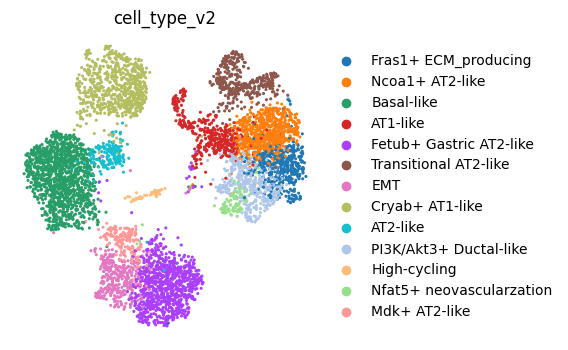

In [16]:
sc.pl.embedding(
    adata,
    basis="umap",
    color=["cell_type_v2"], 
    frameon=False
)

In [17]:
palantir.utils.run_magic_imputation(adata)

<6021x24437 sparse matrix of type '<class 'numpy.float32'>'
	with 75622350 stored elements in Compressed Sparse Row format>

In [18]:
print(adata.layers.keys())

KeysView(Layers with keys: MAGIC_imputed_data)


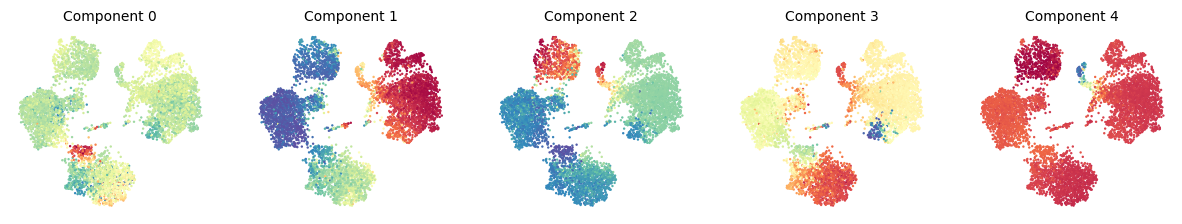

In [19]:
# Visualize the continuous diffusion dimensions
palantir.plot.plot_diffusion_components(adata)
plt.show()

In [24]:
import numpy as np

# 1. Filter your data down to ONLY cells labeled exactly 'AT2-like'
at2_cells = adata[adata.obs['cell_type_v2'] == 'AT2-like']

# 2. Find the median coordinates of these cells in your Harmony UMAP space
umap_coords = at2_cells.obsm['X_umap']
median_coord = np.median(umap_coords, axis=0)

# 3. Find the cell closest to that median center point
distances = np.linalg.norm(umap_coords - median_coord, axis=1)
central_cell_index = np.argmin(distances)

# 4. Extract its exact alphanumeric barcode string
start_cell = at2_cells.obs_names[central_cell_index]

print(f"Manually isolated central AT2-like root barcode: {start_cell}")

Manually isolated central AT2-like root barcode: KP_3_TAGTGCAAGTGATTCC-1


Constructing the Palantir random-walk graph engine...
Sampling and flocking waypoints...
Time for determining waypoints: 0.00021164814631144206 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.0830910325050354 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
Trajectory computation complete. Plotting plasticity and pseudotime maps...


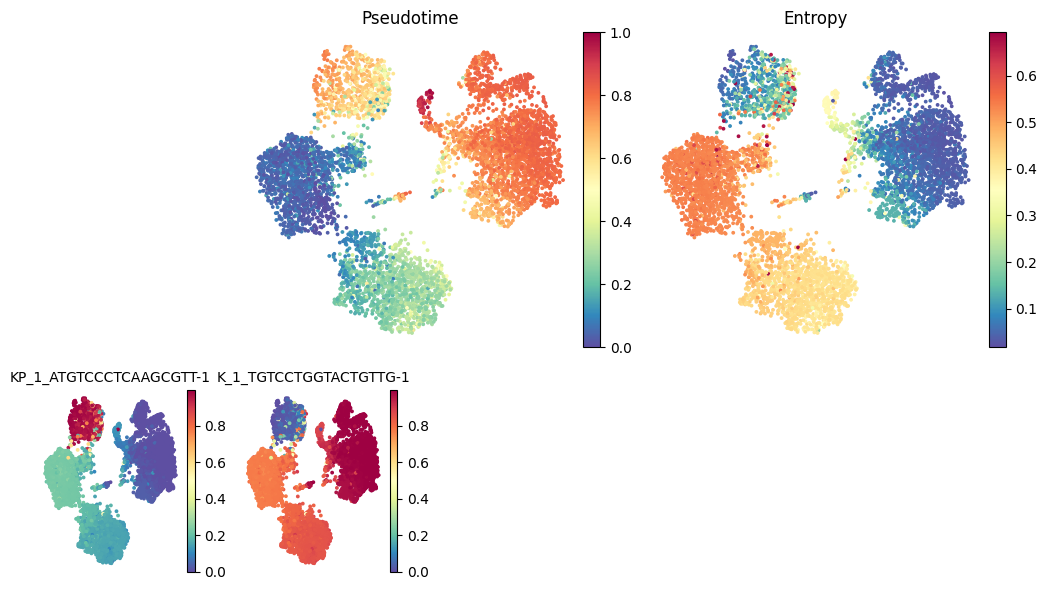

In [25]:
print("Constructing the Palantir random-walk graph engine...")

# Run the core algorithm using your locked-down baseline root barcode
pr_res = palantir.core.run_palantir(
    adata, 
    start_cell, 
    num_waypoints=500
)

print("Trajectory computation complete. Plotting plasticity and pseudotime maps...")

# Display the final pseudotime and differentiation entropy (plasticity) side-by-side
palantir.plot.plot_palantir_results(adata, s=3)
plt.show()

In [28]:
# Print out all accessible properties inside your Palantir results object
print([attr for attr in dir(pr_res) if not attr.startswith('_')])

['branch_probs', 'entropy', 'load', 'pseudotime', 'save', 'waypoints']


In [29]:
# Assign using the exact inspected keyword
adata.obsm['branch_masks'] = pr_res.branch_probs

print("Successfully registered branch masks!")
print("Identified Terminal Branches:")
print(adata.obsm['branch_masks'].columns.tolist())

Successfully registered branch masks!
Identified Terminal Branches:
['KP_1_ATGTCCCTCAAGCGTT-1', 'K_1_TGTCCTGGTACTGTTG-1']


Generating strict boolean masks from array matrix...
Boolean masks successfully built with string columns: ['0', '1']
Computing continuous gene trends over the stabilized boolean graph...
0
[2026-06-03 13:59:29,021] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (1,788) and rank = 1.0.
[2026-06-03 13:59:29,022] [INFO    ] Using covariance function Matern52(ls=1.0).
[2026-06-03 13:59:29,569] [INFO    ] Sigma interpreted as element-wise standard deviation.
1
[2026-06-03 13:59:36,037] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (4,230) and rank = 1.0.
[2026-06-03 13:59:36,039] [INFO    ] Using covariance function Matern52(ls=1.0).
[2026-06-03 13:59:37,661] [INFO    ] Sigma interpreted as element-wise standard deviation.
Trends successfully calculated! Generating cascading heatmaps...


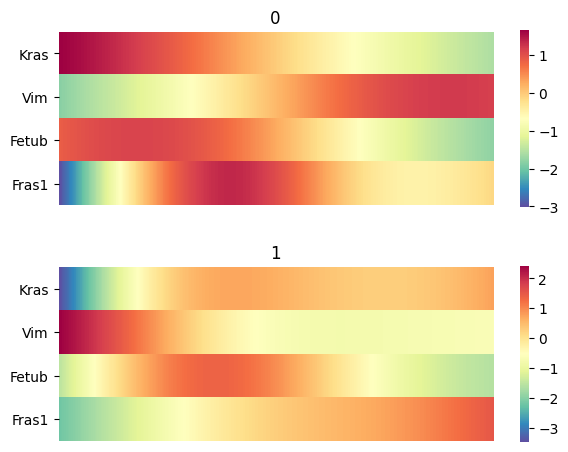

In [36]:
import numpy as np
import pandas as pd

print("Generating strict boolean masks from array matrix...")

# 1. Restore the original DataFrame probabilities so the filter utility can read it
adata.obsm['branch_masks'] = pr_res.branch_probs

# 2. Generate the raw True/False boolean matrix
masks_matrix = palantir.presults.select_branch_cells(adata, q=0.01, eps=0.01)

# 3. Load the matrix into a DataFrame and explicitly force the column headers to be string indices
# This satisfies line 314's string concatenation completely!
boolean_df = pd.DataFrame(
    masks_matrix, 
    index=adata.obs_names, 
    columns=[str(i) for i in range(masks_matrix.shape[1])]
)

# 4. Store the cleanly formatted boolean DataFrame back into obsm
adata.obsm['branch_masks'] = boolean_df

print(f"Boolean masks successfully built with string columns: {boolean_df.columns.tolist()}")
print("Computing continuous gene trends over the stabilized boolean graph...")

# 5. Execute the trend calculator
gene_trends = palantir.presults.compute_gene_trends(
    ad=adata,
    expression_key="MAGIC_imputed_data",
    masks_key="branch_masks",
    pseudo_time_key="palantir_pseudotime"
)

# 6. Define your target driver genes for the cascade
my_tumor_drivers = ["Kras", "Vim", "Fetub", "Fras1"]

print("Trends successfully calculated! Generating cascading heatmaps...")

# 7. Render the cascading trend heatmaps
palantir.plot.plot_gene_trend_heatmaps(adata, my_tumor_drivers)
plt.show()

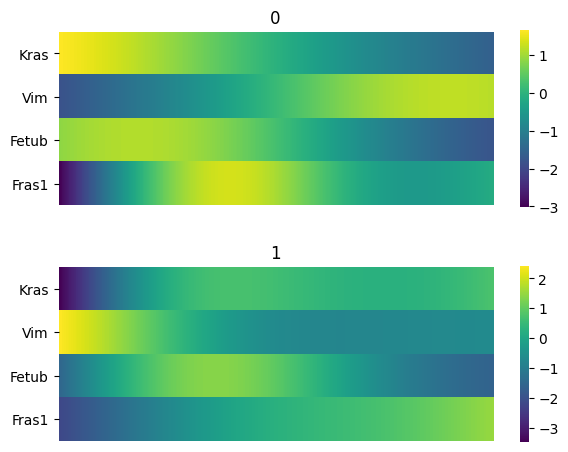

In [37]:
# Plot with enhanced visualization parameters for your manuscript figure
palantir.plot.plot_gene_trend_heatmaps(
    adata, 
    my_tumor_drivers,
    cmap="viridis" # Changes color space to a clean, publication-standard palette
)
plt.show()

[2026-06-03 14:56:20,277] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (1,788) and rank = 1.0.
[2026-06-03 14:56:20,280] [INFO    ] Using covariance function Matern52(ls=1.1870972633361816).
[2026-06-03 14:56:20,284] [INFO    ] Computing 50 landmarks with k-means clustering (random_state=42).
[2026-06-03 14:56:20,362] [INFO    ] Sigma interpreted as element-wise standard deviation.


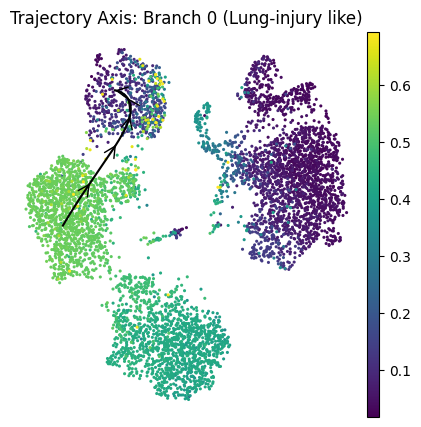

[2026-06-03 14:56:20,809] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (4,230) and rank = 1.0.
[2026-06-03 14:56:20,812] [INFO    ] Using covariance function Matern52(ls=1.1870972633361816).
[2026-06-03 14:56:20,818] [INFO    ] Computing 50 landmarks with k-means clustering (random_state=42).
[2026-06-03 14:56:20,926] [INFO    ] Sigma interpreted as element-wise standard deviation.


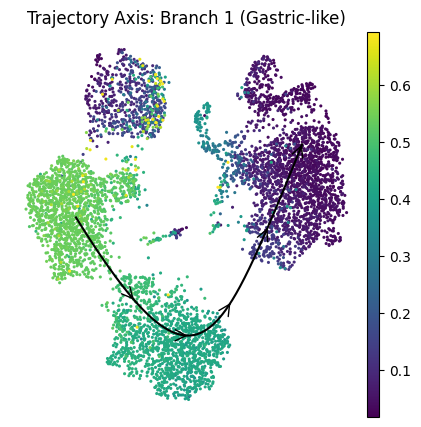

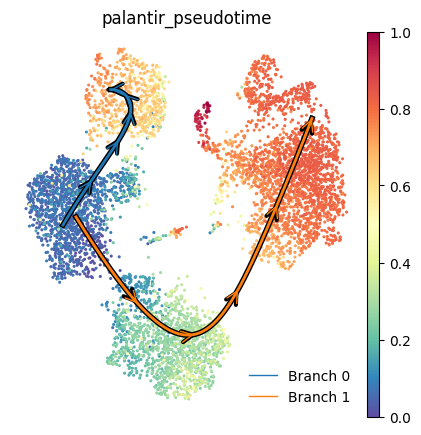

In [42]:
import matplotlib.pyplot as plt

# 1. Plot the continuous path for the Mesenchymal branch (Branch 0)
palantir.plot.plot_trajectory(
    adata, 
    "0", 
    cell_color="palantir_entropy", 
    scanpy_kwargs=dict(cmap="viridis")
)
plt.title("Trajectory Axis: Branch 0 (Lung-injury like)")
plt.show()

# 2. Plot the continuous path for the Gastric branch (Branch 1)
palantir.plot.plot_trajectory(
    adata, 
    "1", 
    cell_color="palantir_entropy", 
    scanpy_kwargs=dict(cmap="viridis")
)
plt.title("Trajectory Axis: Branch 1 (Gastric-like)")
plt.show()

# 3. Plot both global trajectories overlaid simultaneously
palantir.plot.plot_trajectories(adata, pseudotime_interval=(0, 0.9))
plt.show()

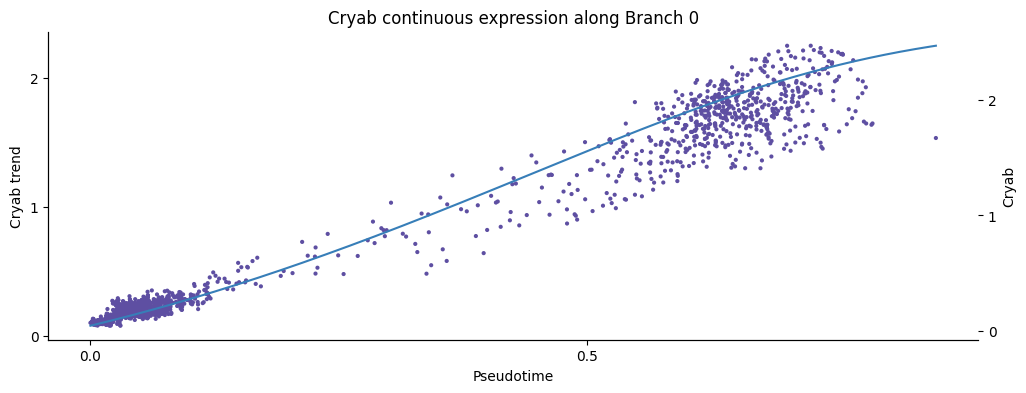

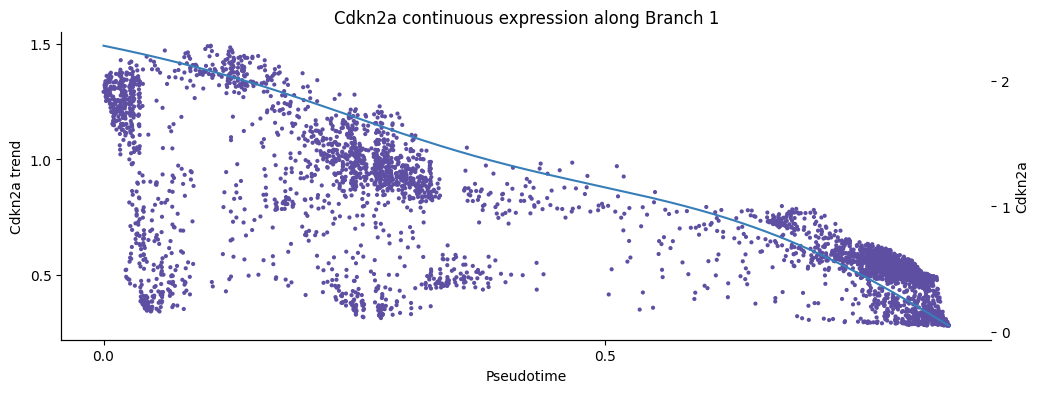

In [45]:
# View single-gene kinetics across the lineages cleanly
palantir.plot.plot_trend(
    ad=adata, 
    branch_name="0", 
    gene="Cryab",  # Looking at Cryab along your Mesenchymal branch
    position_layer="MAGIC_imputed_data" # Maps directly to y_layer internally
)
plt.title("Cryab continuous expression along Branch 0")
plt.show()

# Track Fras1 peaking dynamics across Branch 1
palantir.plot.plot_trend(
    ad=adata, 
    branch_name="1", 
    gene="Cdkn2a", 
    position_layer="MAGIC_imputed_data"
)
plt.title("Cdkn2a continuous expression along Branch 1")
plt.show()

Synchronizing fate matrix keys for Palantir plotter...
Keys synchronized! Verified Slots:
 -> ad.obsm['palantir_fate_probabilities'] columns: ['0', '1']
 -> ad.obsm['branch_masks'] columns: ['0', '1']

Plotting hard boolean branch selections over the layout...


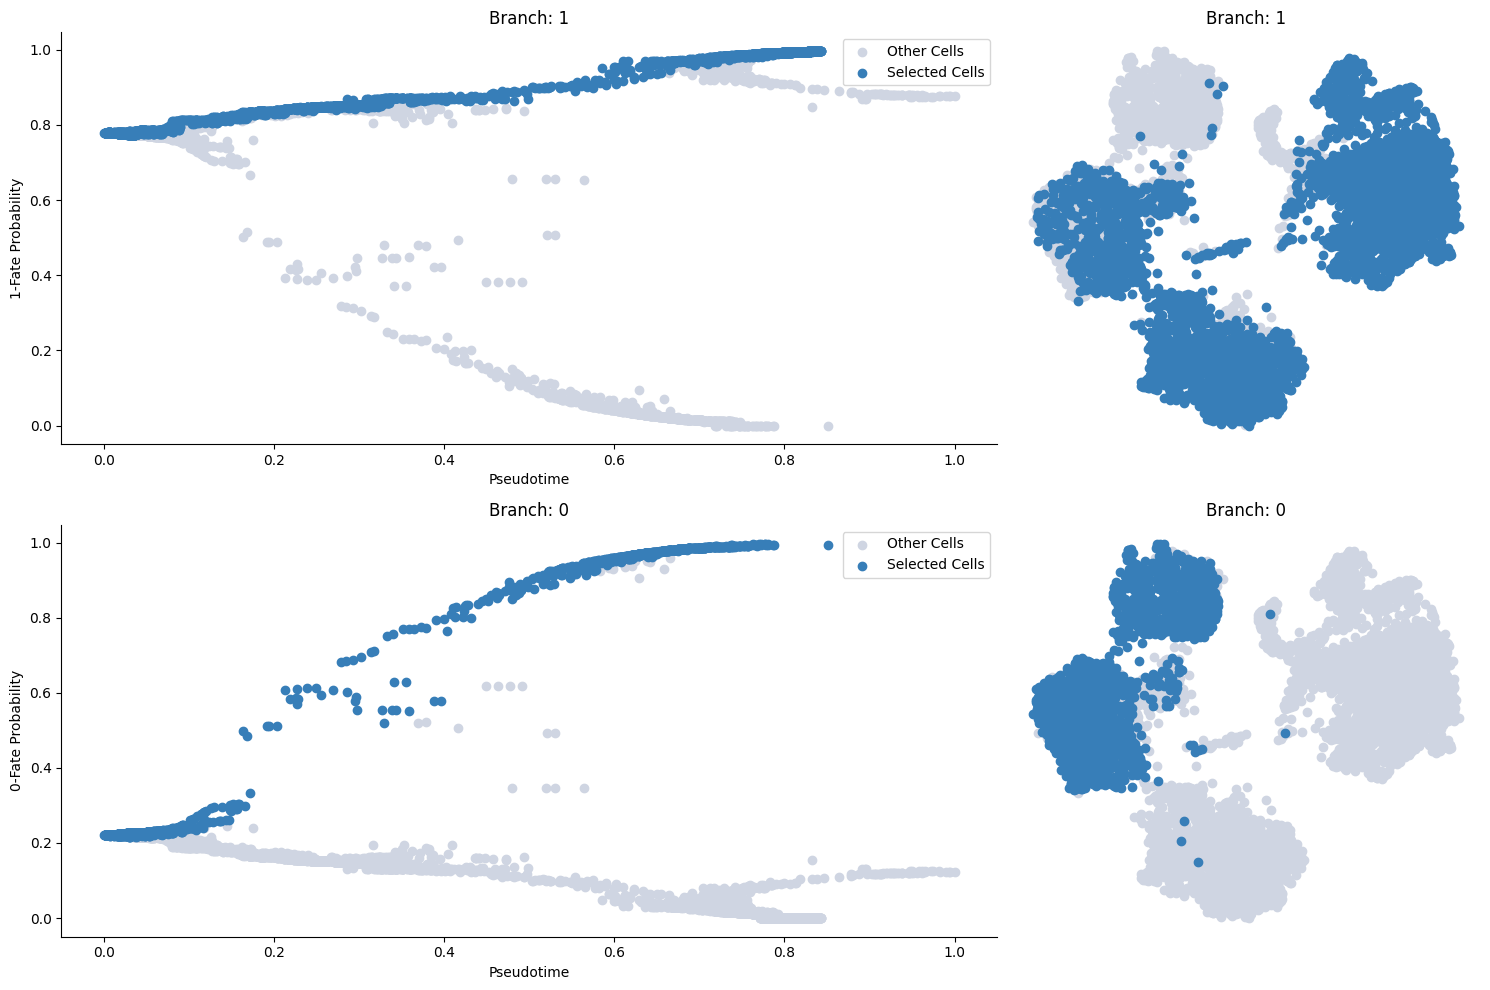

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

print("Synchronizing fate matrix keys for Palantir plotter...")

# 1. Grab your original clean raw probabilities dataframe
raw_probs = pr_res.branch_probs.copy()

# 2. Rename columns to match the string indices '0' and '1'
raw_probs.columns = [str(i) for i in range(raw_probs.shape[1])]

# 3. Store the raw probabilities in the exact default slot the plotter expects
adata.obsm['palantir_fate_probabilities'] = raw_probs

# 4. Re-verify your boolean masks are in the right slot with the same headers
adata.obsm['branch_masks'] = boolean_df

print("Keys synchronized! Verified Slots:")
print(f" -> ad.obsm['palantir_fate_probabilities'] columns: {adata.obsm['palantir_fate_probabilities'].columns.tolist()}")
print(f" -> ad.obsm['branch_masks'] columns: {adata.obsm['branch_masks'].columns.tolist()}")
print("\nPlotting hard boolean branch selections over the layout...")

# 5. Now run the plotter safely
palantir.plot.plot_branch_selection(adata)
plt.show()

[2026-06-03 16:04:06,914] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (4,230) and rank = 1.0.
[2026-06-03 16:04:06,916] [INFO    ] Using covariance function Matern52(ls=1.1870972633361816).
[2026-06-03 16:04:06,919] [INFO    ] Computing 50 landmarks with k-means clustering (random_state=42).
[2026-06-03 16:04:07,090] [INFO    ] Sigma interpreted as element-wise standard deviation.


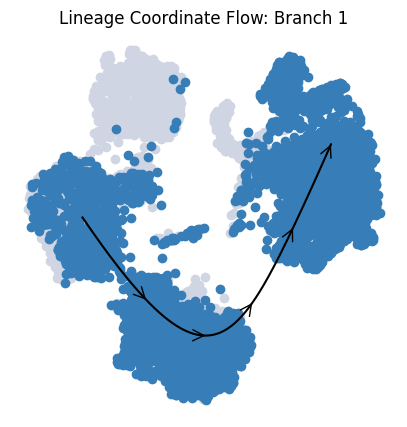

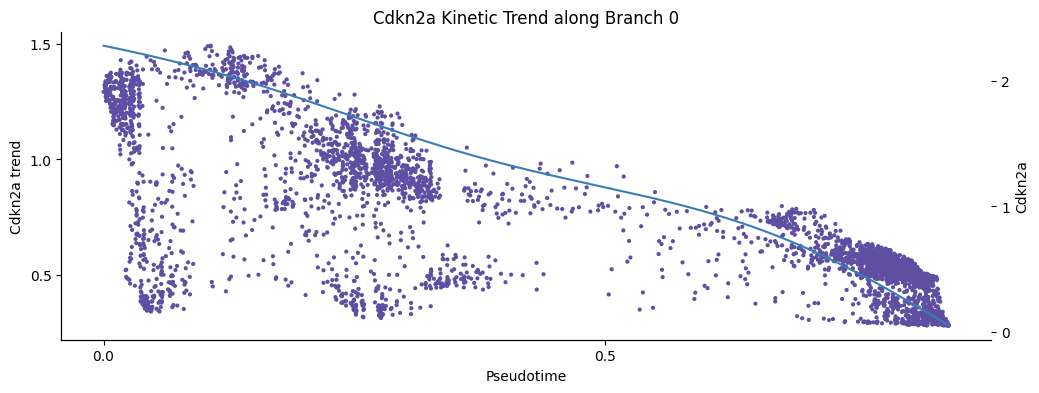

In [50]:
# OPTION A: Draw the structural trajectory vector for Branch 0
palantir.plot.plot_trajectory(adata, branch="1")
plt.title("Lineage Coordinate Flow: Branch 1")
plt.show()

# OPTION B: Plot Cdkn2a expression kinetics over pseudotime for Branch 0
palantir.plot.plot_trend(
    ad=adata, 
    branch_name="1", 
    gene="Cdkn2a", 
    position_layer="MAGIC_imputed_data"
)
plt.title("Cdkn2a Kinetic Trend along Branch 0")
plt.show()

Rendering high-resolution customized trajectory path for Branch 0...
[2026-06-03 16:05:24,010] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (1,788) and rank = 1.0.
[2026-06-03 16:05:24,011] [INFO    ] Using covariance function Matern52(ls=1.1870972633361816).
[2026-06-03 16:05:24,012] [INFO    ] Computing 50 landmarks with k-means clustering (random_state=42).
[2026-06-03 16:05:24,063] [INFO    ] Sigma interpreted as element-wise standard deviation.


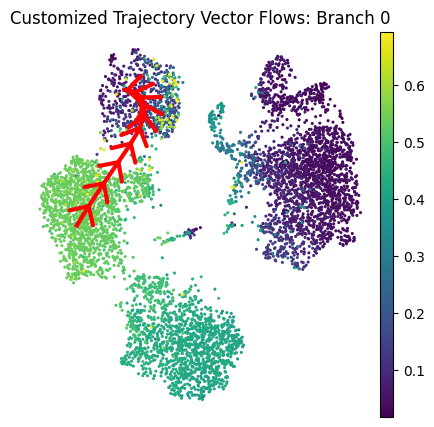

In [51]:
import matplotlib.pyplot as plt

print("Rendering high-resolution customized trajectory path for Branch 0...")

# Execute the customized vector path plotter on your data
palantir.plot.plot_trajectory(
    ad=adata, 
    branch="0",                      # Updated to match your mesenchymal branch
    cell_color="palantir_entropy", 
    n_arrows=10, 
    color="red", 
    scanpy_kwargs=dict(cmap="viridis"), 
    arrowprops=dict(arrowstyle="->,head_length=.5,head_width=.5", lw=3), 
    lw=3, 
    pseudotime_interval=(0, .9)      # Fixed the trailing parenthesis typo here
)

plt.title("Customized Trajectory Vector Flows: Branch 0")
plt.show()

Rendering high-resolution customized trajectory path for Branch 1...
[2026-06-03 16:06:35,136] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (4,230) and rank = 1.0.
[2026-06-03 16:06:35,140] [INFO    ] Using covariance function Matern52(ls=1.1870972633361816).
[2026-06-03 16:06:35,179] [INFO    ] Computing 50 landmarks with k-means clustering (random_state=42).
[2026-06-03 16:06:35,683] [INFO    ] Sigma interpreted as element-wise standard deviation.


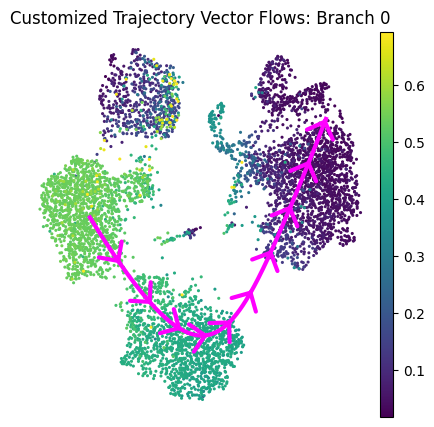

In [54]:
import matplotlib.pyplot as plt

print("Rendering high-resolution customized trajectory path for Branch 1...")

# Execute the customized vector path plotter on your data
palantir.plot.plot_trajectory(
    ad=adata, 
    branch="1",                      # Updated to match your mesenchymal branch
    cell_color="palantir_entropy", 
    n_arrows=10, 
    color="magenta", 
    scanpy_kwargs=dict(cmap="viridis"), 
    arrowprops=dict(arrowstyle="->,head_length=.5,head_width=.5", lw=3), 
    lw=3, 
    pseudotime_interval=(0, .9)      # Fixed the trailing parenthesis typo here
)

plt.title("Customized Trajectory Vector Flows: Branch 0")
plt.show()

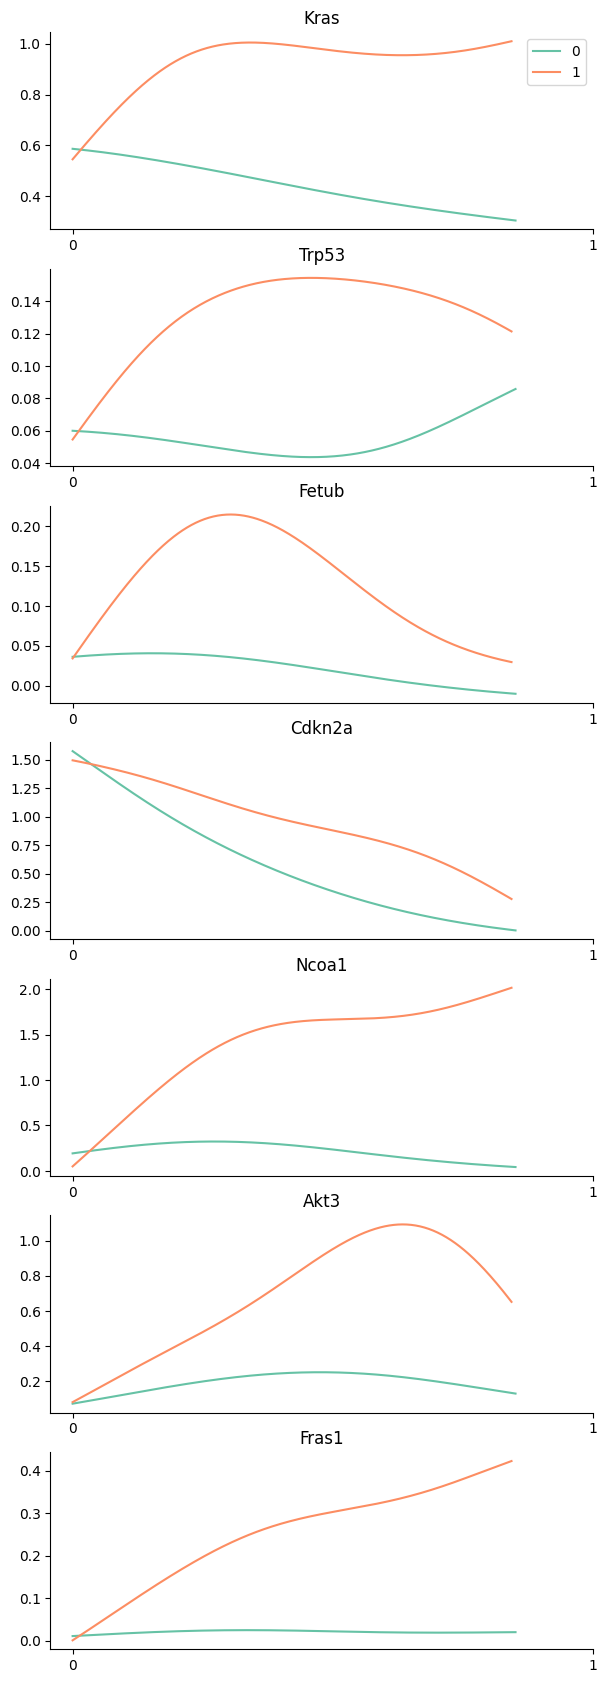

In [56]:
genes = ["Kras", "Trp53", "Fetub", "Cdkn2a","Ncoa1","Akt3","Fras1"]
palantir.plot.plot_gene_trends(adata, genes)
plt.show()

Ensuring boolean lineage masks are mapped to string categories...
Validated 86 markers for kinetic comparison.
Fitting continuous kinetic splines across Branch 0 and Branch 1...
0
[2026-06-03 21:22:08,932] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (1,788) and rank = 1.0.
[2026-06-03 21:22:08,934] [INFO    ] Using covariance function Matern52(ls=1.0).
[2026-06-03 21:22:09,600] [INFO    ] Sigma interpreted as element-wise standard deviation.
1
[2026-06-03 21:22:13,703] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (4,230) and rank = 1.0.
[2026-06-03 21:22:13,704] [INFO    ] Using covariance function Matern52(ls=1.0).
[2026-06-03 21:22:14,129] [INFO    ] Sigma interpreted as element-wise standard deviation.
Generation complete! Rendering comparative lineage heatmaps...


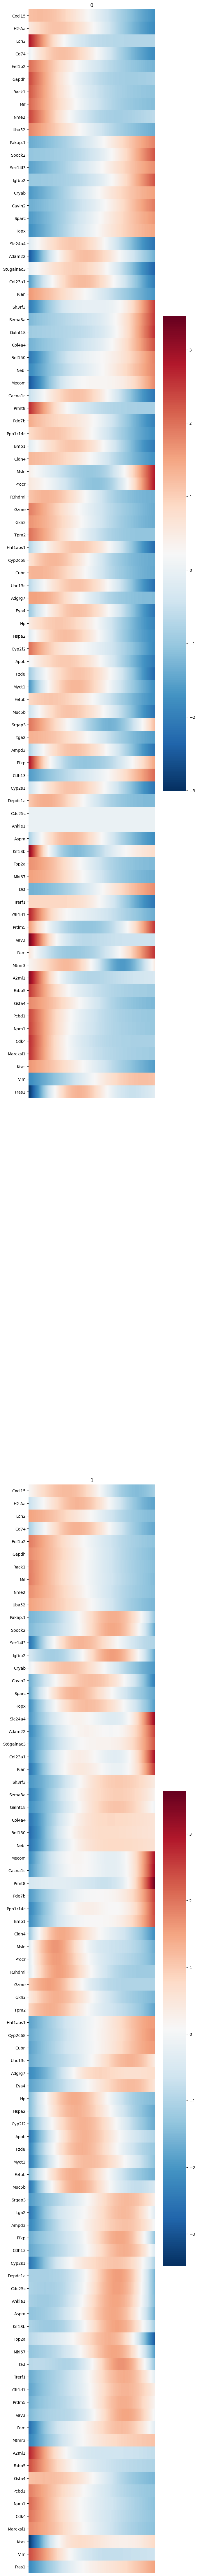

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Ensuring boolean lineage masks are mapped to string categories...")
# 1. Double check that branch_masks matches our clean string data frame columns
# ('0' = lung-like branch, '1' = Gastric-like branch)
adata.obsm['branch_masks'] = boolean_df

# ====================================================================
# MASTER CURATED GENE LIST (STRUCTURED BY YOUR SPECIFIC HIERARCHY)
# ====================================================================
ordered_manuscript_markers = [
    # 1. AT2-like (Root Baseline Group)
    "Cxcl15", "H2-Aa", "Lcn2", "Cd74",
    
    # 2. Basal-like
    "Eef1b2", "Gapdh", "Rack1", "Mif", "Nme2", "Uba52",
    
    # 3. Cryab+ AT1-like
    "Pakap.1", "Spock2", "Sec14l3", "Igfbp2", "Cryab", "Cavin2", "Sparc", "Hopx",
    
    # 4. Ncoa1+ AT2-like
    "Slc24a4", "Adam22", "St6galnac3", "Col23a1", "Rian",
    
    # 5. AT1-like
    "Sh3rf3", "Sema3a", "Galnt18", "Col4a4", "Rnf150", "Nebl",
    
    # 6. Transitional AT2-like
    "Mecom", "Cacna1c", "Prmt8", "Pde7b", "Ppp1r14c", "Bmp1",
    
    # 7. EMT
    "Cldn4", "Msln", "Procr", "R3hdml", "Gzme", "Gkn2", "Tpm2",
    
    # 8. Fras1+ ECM
    "Hnf1aos1", "Cyp2c68", "Cubn", "Unc13c", "Adgrg7", "Eya4",
    
    # 9. Fetub+ Gastric AT2-like
    "Hp", "Hspa2", "Cyp2f2", "Apob", "Fzd8", "Myct1", "Fetub", "Muc5b",
    
    # 10. PI3K/Akt
    "Srgap3", "Itga2", "Ampd3", "Pfkp", "Cdh13", "Cyp2s1",
    
    # 11. Cycling
    "Depdc1a", "Cdc25c", "Ankle1", "Aspm", "Kif18b", "Top2a", "Mki67",
    
    # 12. Nfat5+ neovascularization
    "Dst", "Trerf1", "Glt1d1", "Prdm5", "Vav3", "Pam", "Mtmr3",
    
    # 13. Mdk+ AT2-like (Progression Endpoints)
    "A2ml1", "Fabp5", "Gsta4", "Pcbd1", "Npm1", "Cdk4", "Marcksl1",
    
    # 14. Core Functional Genotypes
    "Kras", "Vim", "Fras1"
]

# Quick filter check to make sure everything requested exists in this specific object matrix
valid_drivers = [gene for gene in ordered_manuscript_markers if gene in adata.var_names]
print(f"Validated {len(valid_drivers)} markers for kinetic comparison.")

# ====================================================================
# RUN GAUSSIAN PROCESS TREND GENERATION
# ====================================================================
print("Fitting continuous kinetic splines across Branch 0 and Branch 1...")
gene_trends = palantir.presults.compute_gene_trends(
    ad=adata,
    expression_key="MAGIC_imputed_data",
    masks_key="branch_masks",
    pseudo_time_key="palantir_pseudotime"
)

# ====================================================================
# RENDER COMPARATIVE MANUSCRIPT HEATMAPS (RdBu_r)
# ====================================================================
print("Generation complete! Rendering comparative lineage heatmaps...")

# This will generate stacked/adjacent heatmaps for Branch 0 and Branch 1 natively,
# sharing the exact same vertical gene indexing so you can contrast behavior.
palantir.plot.plot_gene_trend_heatmaps(
    adata, 
    valid_drivers, 
    cmap="RdBu_r"
)
plt.show()